<a href="https://colab.research.google.com/github/kamalahmadov474/Machine_Learning/blob/main/PCA_on_a_Country_Data_and_Dimensional_Reduction_and_K_means_Check_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STEP 1: Import Libraries



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


STEP 2: Load the Dataset

In [2]:
# Load the dataset from your uploaded file
df = pd.read_csv('/content/Country-data.csv')  # Update the path if needed
df.head()


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


STEP 3: Drop Identifier Column

In [3]:
# Drop 'country' column, which is an identifier and not useful for PCA
features = df.drop(columns=['country'])  # Keep only numerical features
features.head()


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


 STEP 4: Standardize the Data

In [4]:
# Scale the data to mean=0 and std=1 before PCA
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)


STEP 5: Apply PCA to All Components

In [5]:
# Apply PCA without reducing the number of components yet
pca = PCA()
pca_data = pca.fit_transform(scaled_data)


STEP 6: Plot Explained Variance

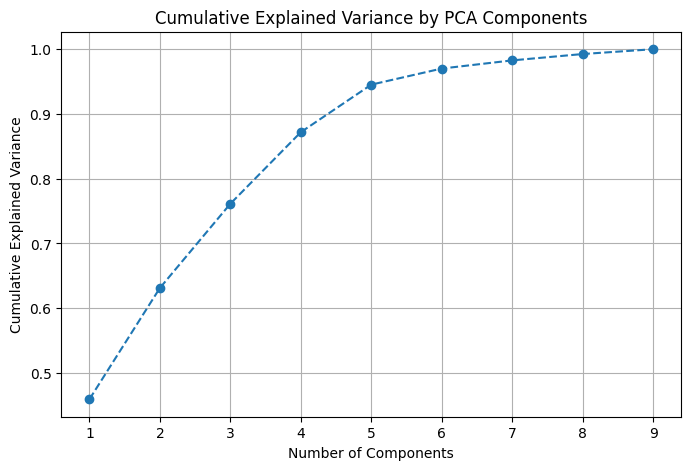

In [6]:
# Plot cumulative explained variance to decide how many components to keep
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_.cumsum(), marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()


STEP 7: Reduce to 2 Principal Components


In [7]:
# Project the data to 2D using PCA
pca_2d = PCA(n_components=2)
data_2d = pca_2d.fit_transform(scaled_data)


STEP 8: Plot 2D PCA Projection

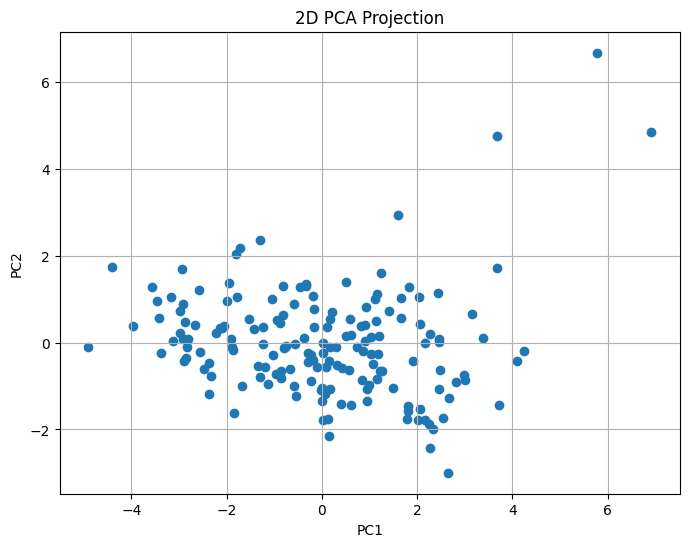

In [8]:
# Plot the data in the 2D PCA space
plt.figure(figsize=(8,6))
plt.scatter(data_2d[:, 0], data_2d[:, 1])
plt.title('2D PCA Projection')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()


STEP 9: Apply K-Means on PCA-Reduced Data

In [9]:
from sklearn.cluster import KMeans

# Define number of clusters
k = 3  # You can change this number based on your needs or test different values

# Apply KMeans to PCA-reduced data
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(data_2d)

# Show cluster labels
print("Cluster labels:\n", labels)


Cluster labels:
 [2 0 0 2 0 0 0 1 1 0 0 1 0 0 0 1 0 2 0 0 0 0 0 1 0 2 2 0 2 1 0 2 2 0 0 0 2
 2 2 0 2 0 1 1 1 0 0 0 0 2 2 1 0 1 1 2 2 0 1 2 1 0 0 2 2 0 2 1 1 0 0 0 0 1
 1 1 0 1 0 0 2 2 1 0 2 0 0 2 2 0 1 1 0 2 2 1 0 2 1 2 0 0 0 0 0 0 2 2 2 0 1
 1 2 2 1 0 2 0 0 0 0 0 1 1 0 0 2 0 0 2 0 1 2 1 1 1 0 0 1 1 0 0 2 0 1 1 0 2
 0 2 2 0 0 0 0 2 0 1 1 1 0 0 0 0 0 2 2]


STEP 10: Visualize Clusters in 2D PCA Space

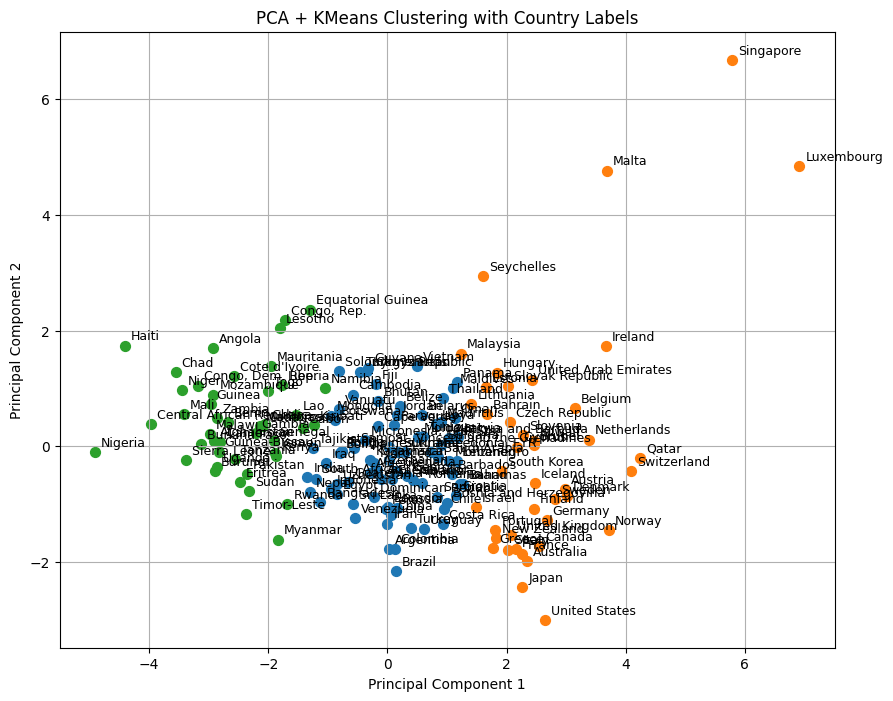

In [10]:
# Add country names to the clustered PCA plot
plt.figure(figsize=(10, 8))
for i in range(len(data_2d)):
    plt.scatter(data_2d[i, 0], data_2d[i, 1], c='C'+str(labels[i]), label=labels[i] if i == 0 else "", s=50)
    plt.text(data_2d[i, 0]+0.1, data_2d[i, 1]+0.1, df['country'][i], fontsize=9)

plt.title('PCA + KMeans Clustering with Country Labels')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()
